## Libraries and variables

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
import segmentation_models as sm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
import pickle
tf.config.run_functions_eagerly(True)


Bad key text.latex.preview in file C:\Users\SOFIA\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file C:\Users\SOFIA\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file C:\Users\SOFIA\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 418 ('savefig.jpeg_quality: 95       # when a jpeg is saved, the default quality parameter.')
You proba

Segmentation Models: using `tf.keras` framework.


In [2]:
IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNEL = 3
IMG_PATH = '../Dataset/Images/'
MASK_PATH = '../Dataset/GT/'

BATCH_SIZE = 1
EPOCHS = 50
BACKBONE = 'inceptionv3'
SPLIT_NUM = 1

In [3]:
# K-fold
with open('../Dataset/' + str(SPLIT_NUM) + '_split.pickle' , 'rb') as f:
    train_index, val_index = pickle.load(f)
        
with open('../Dataset/idx_test.pickle' , 'rb') as f:
    idx_test = pickle.load(f)
    
train_index, val_index, idx_test

(array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
        39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 array([0, 1, 2, 3, 4]),
 [13, 39, 30, 45, 17, 48, 26, 25, 32, 19, 12, 4, 37, 8, 3])

## Data preparation

In [4]:
# Geting data
img_files = os.listdir(IMG_PATH)
mask_files = os.listdir(MASK_PATH)

X = np.zeros((len(img_files), IMG_WIDTH, IMG_HEIGHT, IMG_CHANNEL), dtype=np.float32)
Y = np.zeros((len(img_files), IMG_WIDTH, IMG_HEIGHT, 1), dtype=np.float32)


for i, img_file in enumerate(img_files):
    
    # Image
    image = cv2.imread(IMG_PATH + img_file)
    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH), interpolation = cv2.INTER_LINEAR)
    X[i,:,:,:] = image/255.

    # Mask
    mask = cv2.imread(MASK_PATH + 'gt_c' + str(img_file[:-4]) + '.jpg')
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH), interpolation = cv2.INTER_LINEAR)
    Y[i,:,:,:] = np.expand_dims(mask[:,:,0], axis=-1)/255.


## Segmentation model training

In [5]:
# Define model
def create_linknet(backbone, num_classes, activation):
    model = sm.Linknet(backbone, classes=num_classes, activation = activation)
    return model

# Define optomizer
optim = keras.optimizers.RMSprop(learning_rate=1e-3)

# Metrics
def iou_thresholded(y_true, y_pred, threshold = 0.3, smooth = 1.):
    y_pred = threshold_binarize(y_pred, threshold)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection + smooth)

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

# Losses
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss() 
total_loss = dice_loss + (1 * focal_loss)
total_loss = sm.losses.binary_focal_dice_loss

C:\Users\SOFIA\Anaconda3\lib\site-packages\tensorflow\python\data\ops\dataset_ops.py:3504: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


Epoch 1/50
45/45 [==============================] - 218s 3s/step - loss: 0.9348 - iou_score: 0.2171 - f1-score: 0.3101 - val_loss: 1.0703 - val_iou_score: 8.4998e-09 - val_f1-score: 8.4998e-09
Epoch 2/50
45/45 [==============================] - 133s 3s/step - loss: 0.3799 - iou_score: 0.6668 - f1-score: 0.7863 - val_loss: 1.0700 - val_iou_score: 1.0721e-08 - val_f1-score: 1.0721e-08
Epoch 3/50
45/45 [==============================] - 105s 2s/step - loss: 0.2549 - iou_score: 0.6653 - f1-score: 0.7866 - val_loss: 1.0739 - val_iou_score: 5.3858e-09 - val_f1-score: 5.3858e-09
Epoch 4/50
45/45 [==============================] - 107s 2s/step - loss: 0.2068 - iou_score: 0.6961 - f1-score: 0.8132 - val_loss: 1.1236 - val_iou_score: 7.7362e-04 - val_f1-score: 0.0015
Epoch 5/50
45/45 [==============================] - 91s 2s/step - loss: 0.1986 - iou_score: 0.7053 - f1-score: 0.8165 - val_loss: 1.1231 - val_iou_score: 1.0601e-08 - val_f1-score: 1.0601e-08
Epoch 6/50
45/45 [======================

45/45 [==============================] - 74s 2s/step - loss: 0.0637 - iou_score: 0.8913 - f1-score: 0.9422 - val_loss: 0.5108 - val_iou_score: 0.4099 - val_f1-score: 0.5309
Epoch 46/50
45/45 [==============================] - 75s 2s/step - loss: 0.0575 - iou_score: 0.9011 - f1-score: 0.9478 - val_loss: 0.5117 - val_iou_score: 0.4096 - val_f1-score: 0.5304
Epoch 47/50
45/45 [==============================] - 79s 2s/step - loss: 0.0616 - iou_score: 0.8955 - f1-score: 0.9446 - val_loss: 0.5090 - val_iou_score: 0.4112 - val_f1-score: 0.5324
Epoch 48/50
45/45 [==============================] - 82s 2s/step - loss: 0.0561 - iou_score: 0.9046 - f1-score: 0.9496 - val_loss: 0.5073 - val_iou_score: 0.4123 - val_f1-score: 0.5337
Epoch 49/50
45/45 [==============================] - 74s 2s/step - loss: 0.0581 - iou_score: 0.9005 - f1-score: 0.9473 - val_loss: 0.5063 - val_iou_score: 0.4127 - val_f1-score: 0.5343
Epoch 50/50
45/45 [==============================] - 78s 2s/step - loss: 0.0569 - iou_s

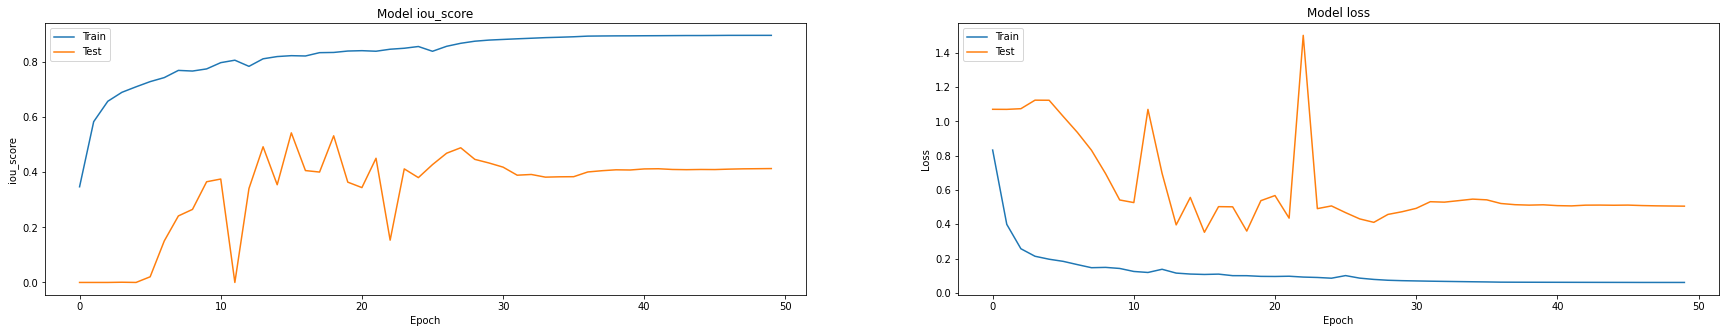

In [6]:
# K-fold
with open('../Dataset/' + str(SPLIT_NUM) + '_split.pickle' , 'rb') as f:
    train_index, val_index = pickle.load(f)
        
        
# Define callbacks for learning rate scheduling and best checkpoints saving
callbacks = [
            keras.callbacks.ModelCheckpoint('./'+ str(SPLIT_NUM) +'_best_model.h5', save_weights_only=True,
                                            save_best_only=True, monitor = 'val_iou_score', mode='max'),
            keras.callbacks.ReduceLROnPlateau(),
        ]


model = create_linknet(BACKBONE, num_classes=1, activation = 'sigmoid')

# Compile
model.compile(optim, total_loss, metrics)


# Train model
history = model.fit(
            X[train_index,:,:,:], 
            Y[train_index,:,:,:], 
            validation_data=(X[val_index,:,:,:],Y[val_index,:,:,:]), 
            batch_size=BATCH_SIZE, 
            epochs=EPOCHS, 
            callbacks=callbacks,
            verbose=1)


# Plot training & validation iou_score values
plt.figure(figsize=(30, 5))
plt.subplot(121)
plt.plot(history.history['iou_score'])
plt.plot(history.history['val_iou_score'])
plt.title('Model iou_score')
plt.ylabel('iou_score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Model Evaluation

In [7]:
# model = create_linknet(BACKBONE, num_classes=1, activation = 'sigmoid')
# model.load_weights('./1_best_model.h5')
Y_pred = model.predict(X[idx_test,:,:,:])

Y_pred[Y_pred >= 0.3] = 1
Y_pred[Y_pred < 0.3] = 0

In [8]:
# Evaluation functions
def iou_coef(y_true, y_pred, smooth=1):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
    union = K.sum(y_true,[1,2,3])+K.sum(y_pred,[1,2,3])-intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
    return iou

def dice_coef(y_true, y_pred, smooth=1):
    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
    dice = K.mean((2. * intersection + smooth)/(union + smooth), axis=0)
    return dice


# Perfomance results 
print('Dice coef: ' + str(dice_coef(tf.cast(Y[idx_test], dtype=Y_pred.dtype), Y_pred, smooth=1).numpy()))
print('IOU coef: ' + str(iou_coef(tf.cast(Y[idx_test], dtype=Y_pred.dtype), Y_pred, smooth=1).numpy()))

Dice coef: 0.81498027
IOU coef: 0.73655784


## Visualization of results on test dataset

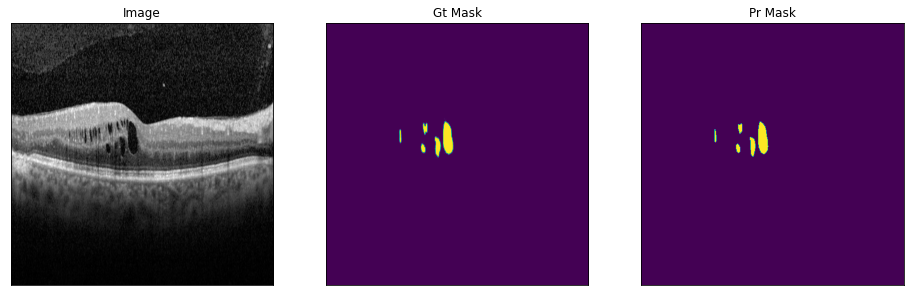

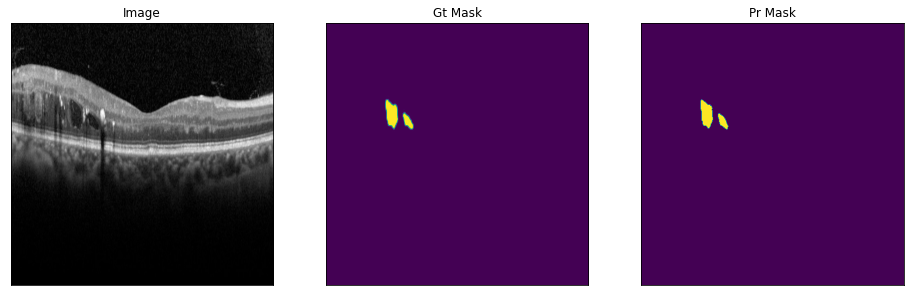

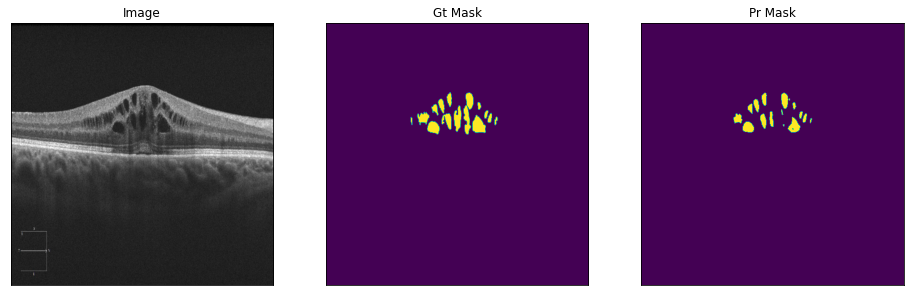

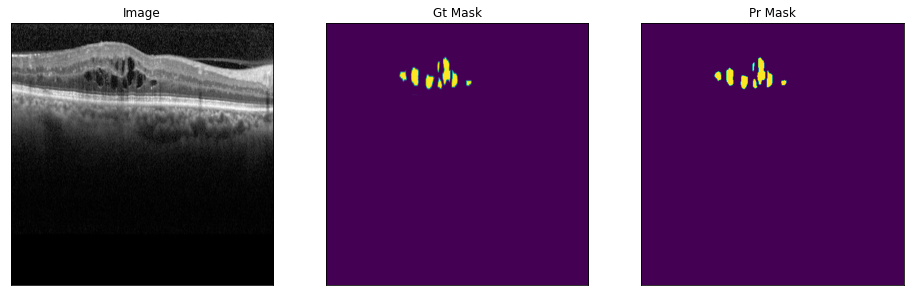

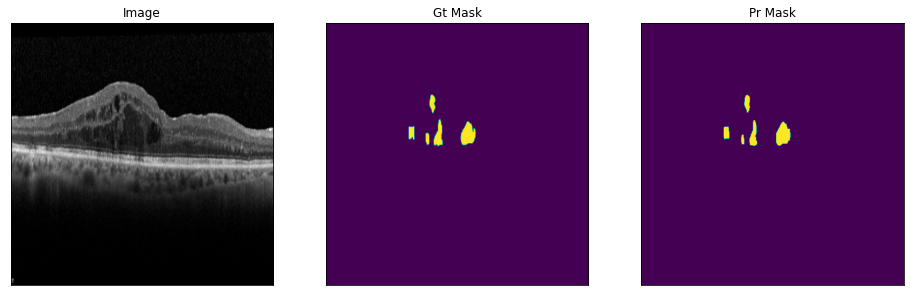

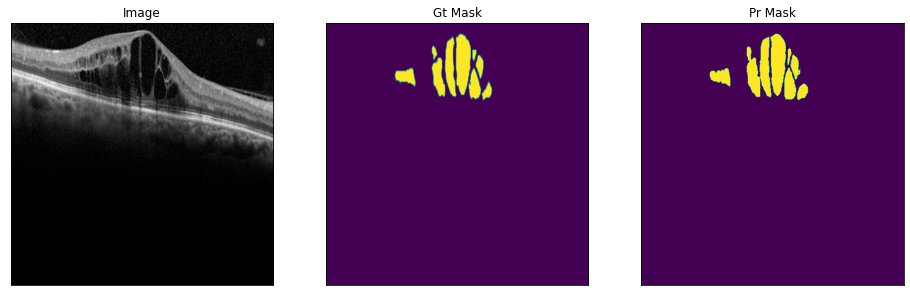

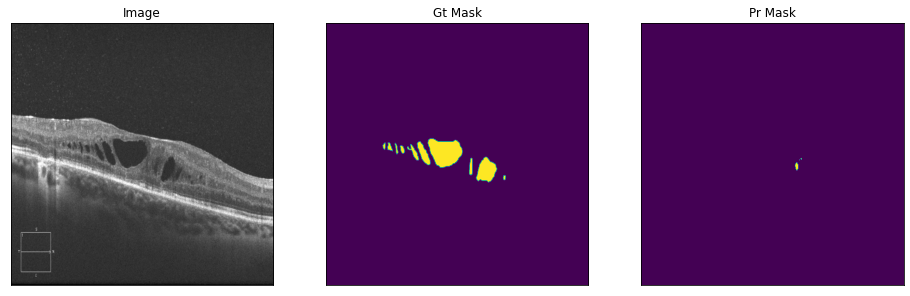

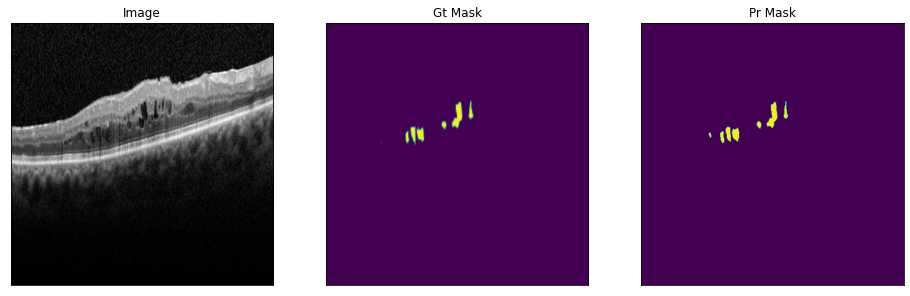

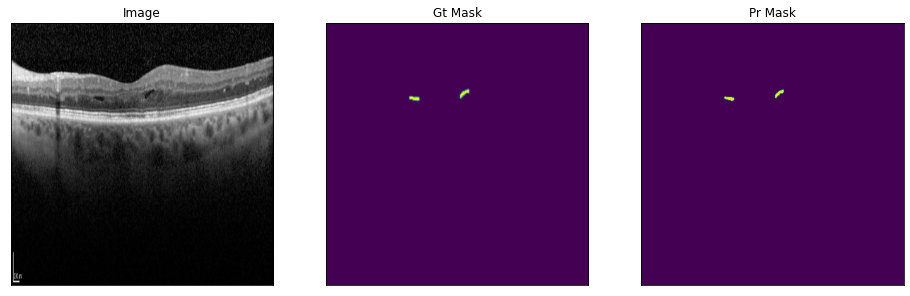

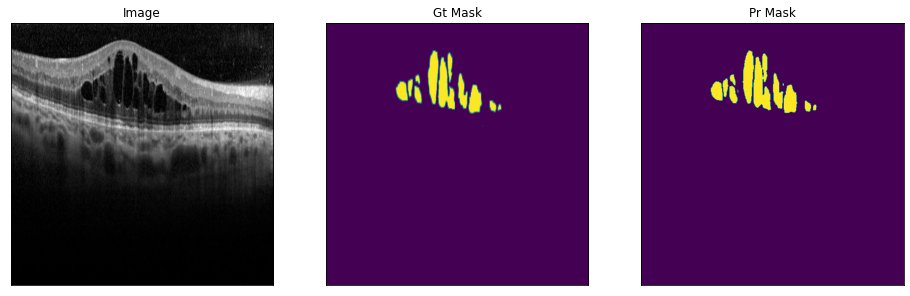

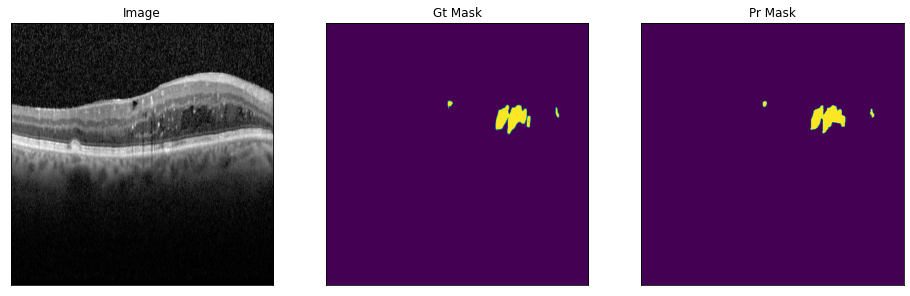

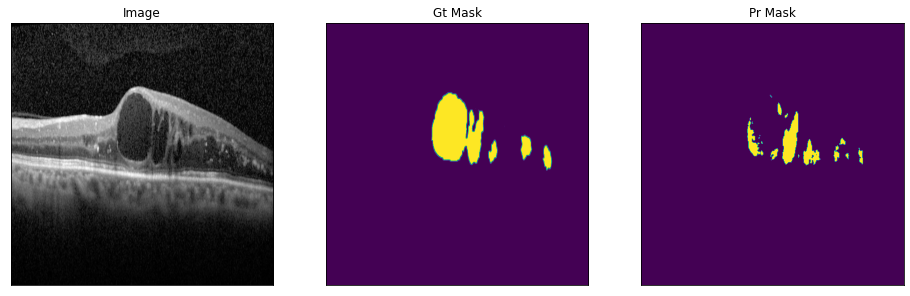

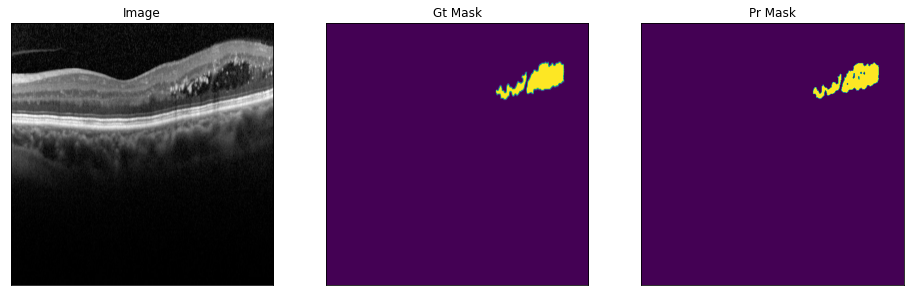

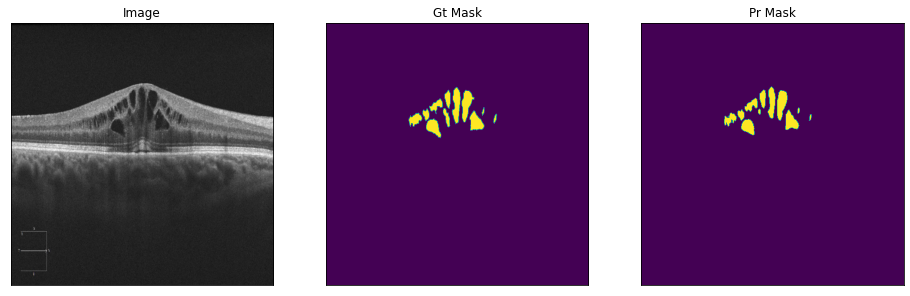

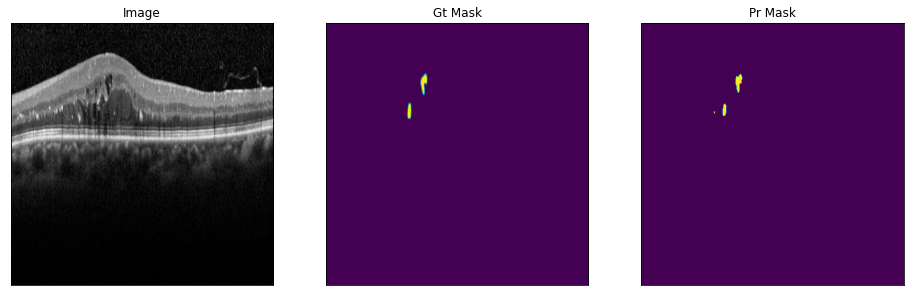

In [9]:
## 

# helper function for data visualization
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()
    
# n = 5
# ids = np.random.choice(np.arange(len(idx_test)), size=n)

for i in range(len(idx_test)):
    
    image = X[idx_test][i]
    gt_mask = Y[idx_test][i]
    pr_mask = Y_pred[i]
    
    visualize(
        image=image.squeeze(),
        gt_mask=gt_mask[..., 0].squeeze(),
        pr_mask=pr_mask[..., 0].squeeze(),
    )